In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
import torchvision
from transformers import CLIPProcessor, CLIPTextModelWithProjection
import torch.optim as optim

/home/rianbutala/projects/sd-v5/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("MohamedRashad/midjourney-detailed-prompts")
print(next(iter(ds["train"]))['short_prompt'])
print(next(iter(ds["train"]))['image'])

A serene white wolf, its fur a rainbow kaleidoscope, poised in black emptiness.
<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=864x1728 at 0x7F8BB6F36930>


In [3]:
transforms = torchvision.transforms.Compose([
  torchvision.transforms.Resize((256, 256)),
  torchvision.transforms.ToTensor()
])

class ImageDataset(Dataset):
    def __init__(self, dataset, transforms=None):
        self.dataset = dataset
        self.transforms = transforms
        self.dataset_iter = iter(self.dataset)

    def __len__(self):
        return int(1e10)

    def __getitem__(self, idx):
        try:
          item = next(self.dataset_iter)
        except StopIteration:
          self.dataset_iter = iter(self.dataset)
          item = next(self.dataset_iter)
        image = item['image'] # PIL image
        image = transforms(image) if self.transforms else image
        return image

In [4]:

# class TextImageDataset(Dataset):
#     def __init__(self, dataset, transforms=None):
#         self.dataset = dataset
#         self.transforms = transforms
#         self.dataset_iter = iter(self.dataset)
#         self.processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
#         model_id="openai/clip-vit-base-patch32"
#         self.clip_model = CLIPTextModelWithProjection.from_pretrained(model_id)

#     def embed_text(self, text):
#         # inputs = tokenizer([text], return_tensors="pt")
#         inputs = self.processor(text=[text], return_tensors="pt", padding="max_length", truncation=True, max_length=77)
#         # print(type(inputs))
#         with torch.inference_mode():
#           # outputs = clip_model(**inputs)    
#           outputs = self.clip_model(**inputs)
#         embeds=outputs.text_embeds # B,256
#         chunks = torch.chunk(embeds, chunks=2, dim=1)# tuple: B,256 each
#         embeds = torch.cat(chunks, dim=0) # B,2,256
#         return embeds
#     def __len__(self):
#         return int(1e10)

#     def __getitem__(self, idx):
#         try:
#           item = next(self.dataset_iter)
#         except StopIteration:
#           self.dataset_iter = iter(self.dataset)
#           item = next(self.dataset_iter)
#         image = item['jpg'] # PIL image
#         prompt = item['json']['prompt'] # text
#         prompt = self.embed_text(prompt) # B,2,256
#         image = transforms(image) if self.transforms else image
#         return image, prompt

class TextImageDataset(Dataset):
    def __init__(self, dataset, transforms=None):
        self.dataset = dataset
        self.transforms = transforms
        self.dataset_iter = iter(self.dataset)

    def __len__(self):
        return int(1e10)

    def __getitem__(self, idx):
        try:
          item = next(self.dataset_iter)
        except StopIteration:
          self.dataset_iter = iter(self.dataset)
          item = next(self.dataset_iter)
        image = item['image'] # PIL image
        prompt = item['short_prompt'] # text
        image = transforms(image) if self.transforms else image
        return image, prompt

In [5]:
ids = ImageDataset(ds["train"], transforms=transforms)
dataloader = DataLoader(ids, batch_size=16, pin_memory=True, persistent_workers=True, num_workers=12)
# print(f" testing ids batch {next(iter(dataloader)).shape}") # B,3,256,256}")
pds = TextImageDataset(ds["train"], transforms=transforms)
batch_size=64
pdataloader = DataLoader(pds, batch_size=batch_size, pin_memory=True, persistent_workers=True, num_workers=12, prefetch_factor=8)
# print(f" testing pds batch {next(iter(pdataloader))[0].shape}") # B,3,256,256}")
# print(f" testing pds batch {next(iter(pdataloader))[1].shape}") # B,2,256}")

In [6]:
from components.model2 import DiffusionModel
from tqdm import tqdm
train_autoencoder=False
save_autoencoder=True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device=torch.device('cpu')
model = DiffusionModel(num_layers=16).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)


steps = 10000

if train_autoencoder:
  pbar = tqdm(range(steps))
  dl_iter = iter(dataloader)
  for step in pbar:
    try: 
      images = next(dl_iter)
    except StopIteration:
      dl_iter = iter(dataloader)
      images = next(dl_iter)

    images = images.to(device) # B,3,256,256
    # images = next(iter(dataloader)).to(device) # B,3,256,256
    image_enc = model.encode(images)
    image_dec = model.decode(image_enc)

    loss = F.mse_loss(image_dec, images)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    pbar.set_description(f"loss: {loss.item():.4f}")
  if save_autoencoder:
    torch.save(model.state_dict(), "checkpoints/model-v1.pth")
else:
  model.load_state_dict(torch.load("checkpoints/model-v1.pth", map_location=device))
  print("loaded ae")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 47481.78it/s]
[transformers] CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder

loaded ae


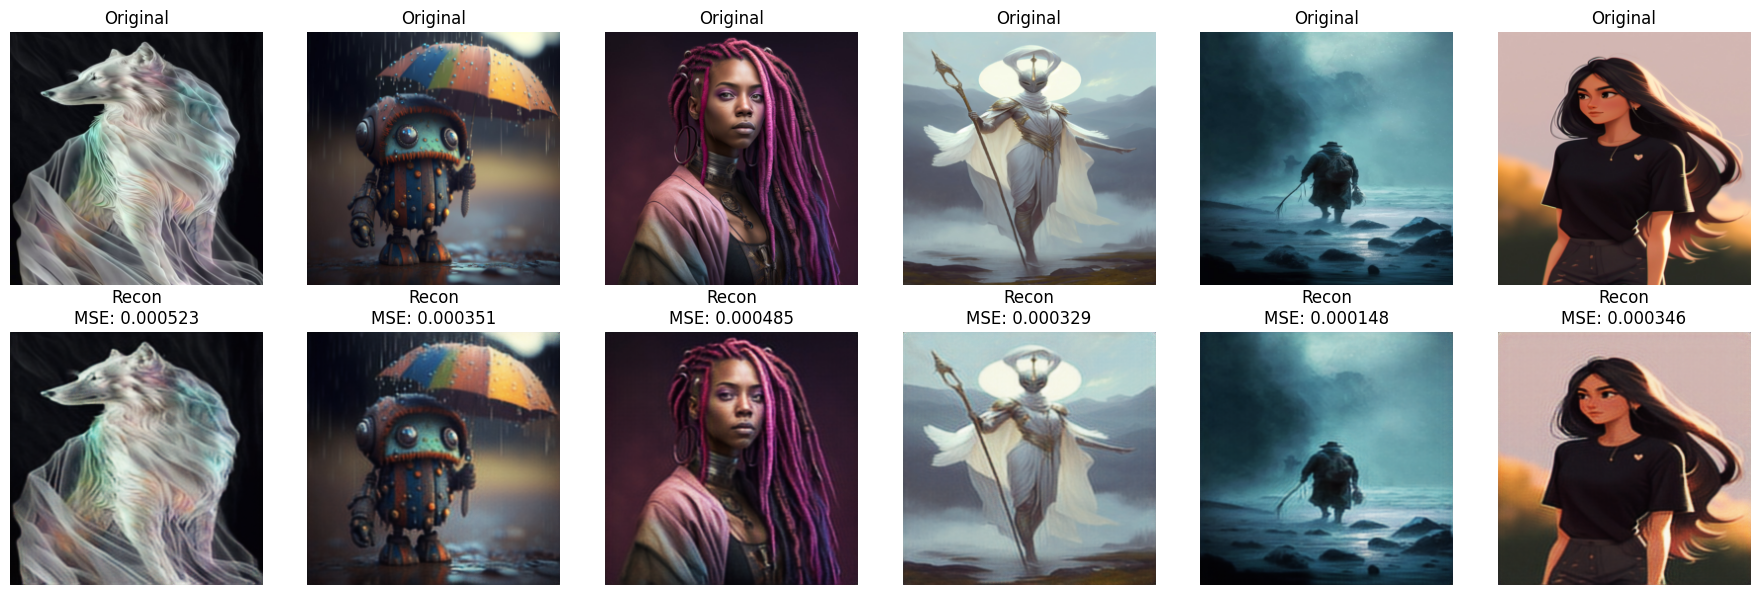

Image 0: MSE = 0.000523
Image 1: MSE = 0.000351
Image 2: MSE = 0.000485
Image 3: MSE = 0.000329
Image 4: MSE = 0.000148
Image 5: MSE = 0.000346


In [7]:
# Visualize original vs reconstructed + per-image MSE
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torchvision.utils as vutils

model.eval()

with torch.no_grad():
    images = next(iter(dataloader)).to(device)
    image_enc = model.encode(images)
    image_dec = model.decode(image_enc)

# Compute per-image MSE (mean over C,H,W but not batch)
per_image_mse = F.mse_loss(image_dec, images, reduction="none")
per_image_mse = per_image_mse.mean(dim=(1,2,3))  # shape: (B,)

# Move to CPU for plotting
images = images.cpu()
image_dec = image_dec.cpu()
per_image_mse = per_image_mse.cpu()

# If your model uses [-1,1], uncomment:
# images = (images + 1) / 2
# image_dec = (image_dec + 1) / 2

images = images.clamp(0, 1)
image_dec = image_dec.clamp(0, 1)

n = 6  # number of samples to show

fig, axes = plt.subplots(2, n, figsize=(3*n, 6))

for i in range(n):
    # Original
    axes[0, i].imshow(images[i].permute(1,2,0))
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    # Reconstruction
    axes[1, i].imshow(image_dec[i].permute(1,2,0))
    axes[1, i].set_title(f"Recon\nMSE: {per_image_mse[i]:.6f}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

# Also print numeric values clearly
for i in range(n):
    print(f"Image {i}: MSE = {per_image_mse[i].item():.6f}")

In [175]:
for param in model.encoder.parameters():
    param.requires_grad = False
for param in model.decoder.parameters():
    param.requires_grad = False
print("ae frozen")

train_rf = True
save_rf = True
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model_id="openai/clip-vit-base-patch32"
clip_model = CLIPTextModelWithProjection.from_pretrained(model_id).to(device).eval()

def embed_text(text):
  # inputs = tokenizer([text], return_tensors="pt")
  inputs =processor(text=list(text), return_tensors="pt", padding=True, truncation=True, max_length=77).to(device)
  # print(type(inputs))
  with torch.inference_mode():
    # outputs = clip_model(**inputs)    
    outputs =clip_model(**inputs)
  embeds=outputs.text_embeds.unsqueeze(1) # B,1, 512
  # chunks = torch.chunk(embeds, chunks=2, dim=2)# tuple: B,1,256 each
  # embeds = torch.cat(chunks, dim=1) # B,2,256
  return embeds

cfg_prob=0.1
cfg_prompt=embed_text(['null']).to(device).repeat(batch_size,1,1)
compiled_model = torch.compile(model)
rf_steps = 100000
pbar = tqdm(range(rf_steps))
pd_iter = iter(pdataloader)
if train_rf:
  for step in pbar:
      try:
          images, prompts = next(pd_iter)
      except StopIteration:
          pd_iter = iter(pdataloader)
          images, prompts = next(pd_iter)

      images = images.to(device) # B,3,256,256
      # prompts = prompts.to(device) # B,2,256
      if torch.rand(1) < cfg_prob:
        prompts = cfg_prompt
      else:
        prompts=embed_text(prompts)

      t = torch.rand([images.size(0),1,1], device=device) # B,1

      with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        x1 = compiled_model.encode(images)
        x0 = torch.randn_like(x1)
        
        # print(f"sanity shape check: x0: {x0.shape}, x1: {x1.shape}, t: {t.shape}")
        x_t = x0*(1-t)+x1*t
        
        predicted_velocity=compiled_model(x_t, prompts, t)
        target_velocity = x1-x0

      loss = F.mse_loss(predicted_velocity, target_velocity)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      if step%20 ==0:
        pbar.set_description(f"loss: {loss.item():.4f}")
  if save_rf:
    torch.save(model.state_dict(), "checkpoints/model-v1.pth")
else:
  model.load_state_dict(torch.load("checkpoints/model-v1.pth"))


ae frozen


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 58168.10it/s]
[transformers] CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder

KeyboardInterrupt: 

torch.Size([1, 1, 512])


100%|██████████| 50/50 [00:00<00:00, 104.29it/s]


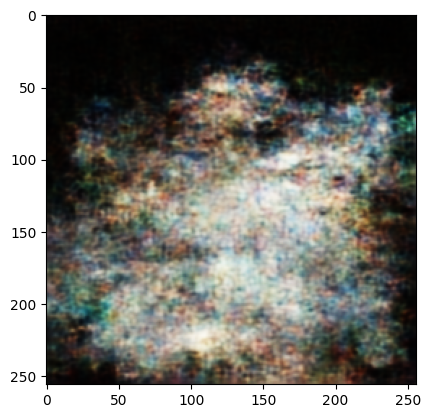

In [409]:
model.eval()
z = torch.randn([1,256,512]).to(device)
steps = 50
guidance_scale=2
prompt = (["A serene white wolf, its fur a rainbow kaleidoscope, poised in black emptiness."])
prompt_emb = embed_text(prompt)
null_prompt_emb = embed_text((['null']))
print(prompt_emb.shape)
with torch.no_grad():
  for i in tqdm(range(steps)):
    t = torch.tensor(i/steps).to(device)
    v_null_prompt = model(z, null_prompt_emb, t)
    v_pred = model(z, prompt_emb, t) 

    v_latent = v_null_prompt + guidance_scale*(v_pred-v_null_prompt)
    z = v_latent* 1/steps + z

  image = model.decode(z)
plt.imshow(image.squeeze(0).permute(1,2,0).cpu().detach().numpy())

In [109]:
print(f"{sum([p.numel() for p in model.parameters()])/1_000_000:.1f}m parameters")

93.4m parameters
